In [14]:
# ============================================================
# RESTAURANT REVIEWS ANALYSIS - YELP DATASET
# ============================================================
# Author: Your Name
# Date: May 2026
# Description: Exploratory and sentiment analysis of 70,000+
# restaurant reviews using the Yelp Open Dataset.
# ============================================================

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from textblob import TextBlob
from wordcloud import WordCloud
import os

sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 120

os.makedirs('/Users/vipont/Desktop/data/outputs', exist_ok=True)

print("Libraries loaded successfully")

Libraries loaded successfully


In [16]:
# Loading the full business dataset (~150k businesses)
# and a 100k sample of reviews to avoid RAM overload

df_business = pd.read_json(
    '/Users/vipont/Desktop/data/yelp_academic_dataset_business.json',
    lines=True
)

df_reviews = pd.read_json(
    '/Users/vipont/Desktop/data/yelp_academic_dataset_review.json',
    lines=True,
    nrows=100000
)

print(f"Businesses loaded:  {len(df_business):,}")
print(f"Reviews loaded:     {len(df_reviews):,}")

Businesses loaded:  150,346
Reviews loaded:     100,000


In [17]:
# The dataset includes all business types (shops, doctors, etc.)
# We filter only businesses categorized as "Restaurants"

restaurants = df_business[
    df_business['categories'].str.contains('Restaurants', na=False)
]

print(f"Total businesses:      {len(df_business):,}")
print(f"Restaurants only:      {len(restaurants):,}")
print(f"Percentage of total:   {len(restaurants)/len(df_business)*100:.1f}%")

Total businesses:      150,346
Restaurants only:      52,268
Percentage of total:   34.8%


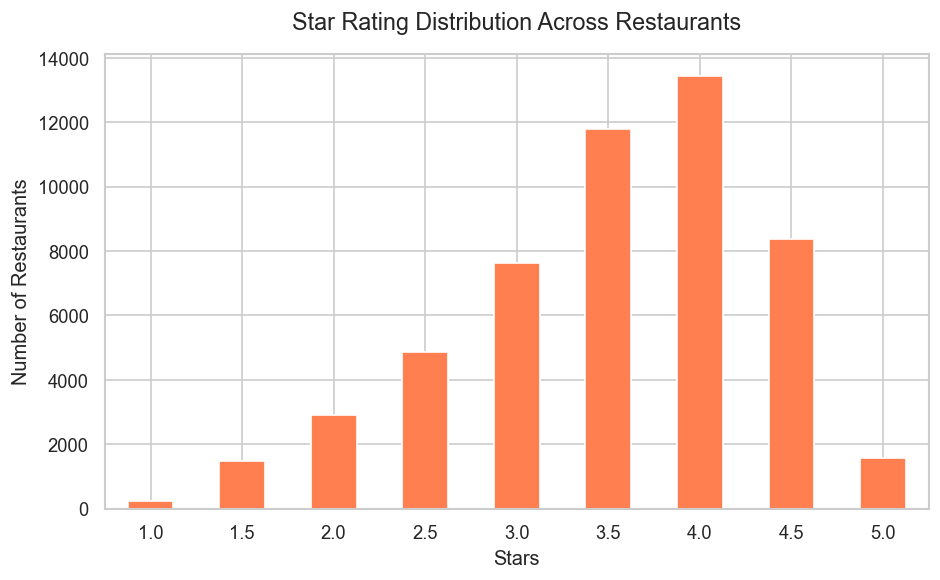

Insight: The most common rating is 4.0 stars


In [18]:
# How are star ratings distributed across restaurants?

plt.figure(figsize=(8,5))
restaurants['stars'].value_counts().sort_index().plot(
    kind='bar', color='coral', edgecolor='white'
)
plt.title('Star Rating Distribution Across Restaurants', fontsize=14, pad=15)
plt.xlabel('Stars')
plt.ylabel('Number of Restaurants')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('/Users/vipont/Desktop/data/outputs/01_star_distribution.png')
plt.show()

most_common = restaurants['stars'].mode()[0]
print(f"Insight: The most common rating is {most_common} stars")

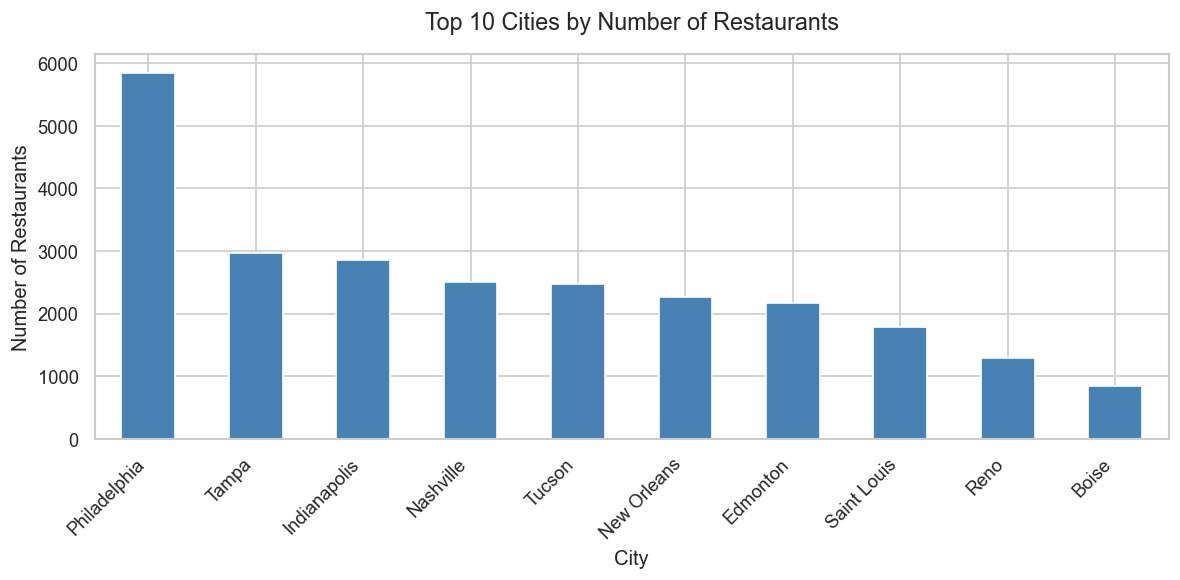

Insight: The city with the most restaurants is Philadelphia


In [19]:
# Which cities have the most restaurants in the dataset?

plt.figure(figsize=(10,5))
restaurants['city'].value_counts().head(10).plot(
    kind='bar', color='steelblue', edgecolor='white'
)
plt.title('Top 10 Cities by Number of Restaurants', fontsize=14, pad=15)
plt.xlabel('City')
plt.ylabel('Number of Restaurants')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('/Users/vipont/Desktop/data/outputs/02_top_cities.png')
plt.show()

top_city = restaurants['city'].value_counts().index[0]
print(f"Insight: The city with the most restaurants is {top_city}")

In [20]:
# We join reviews with restaurant data using business_id as the key

df_merged = df_reviews.merge(
    restaurants[['business_id', 'name', 'city', 'state', 'stars']],
    on='business_id',
    how='inner'
)

print(f"Total reviews loaded:           {len(df_reviews):,}")
print(f"Restaurant reviews:             {len(df_merged):,}")
print(f"Discarded (not restaurant):     {len(df_reviews)-len(df_merged):,}")

Total reviews loaded:           100,000
Restaurant reviews:             72,124
Discarded (not restaurant):     27,876


In [21]:
# We use TextBlob to calculate polarity for each review
# Polarity score: -1 (very negative) -> 0 (neutral) -> +1 (very positive)
# This may take 1-2 minutes

print("Calculating sentiment scores... (this may take a moment)")

df_merged['sentiment_score'] = df_merged['text'].apply(
    lambda x: TextBlob(str(x)).sentiment.polarity
)

def classify_sentiment(score):
    if score > 0.1:
        return 'Positive'
    elif score < -0.1:
        return 'Negative'
    else:
        return 'Neutral'

df_merged['sentiment'] = df_merged['sentiment_score'].apply(classify_sentiment)

total = len(df_merged)
for cat, count in df_merged['sentiment'].value_counts().items():
    print(f"{cat}: {count:,} reviews ({count/total*100:.1f}%)")

Calculating sentiment scores... (this may take a moment)
Positive: 57,331 reviews (79.5%)
Neutral: 10,913 reviews (15.1%)
Negative: 3,880 reviews (5.4%)


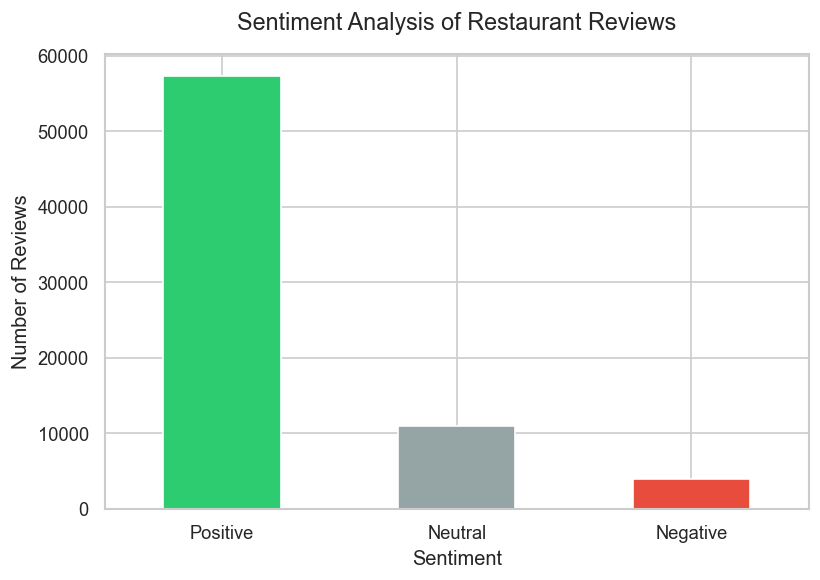

In [22]:
plt.figure(figsize=(7,5))
colors = ['#2ecc71', '#95a5a6', '#e74c3c']
df_merged['sentiment'].value_counts().plot(
    kind='bar', color=colors, edgecolor='white'
)
plt.title('Sentiment Analysis of Restaurant Reviews', fontsize=14, pad=15)
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('/Users/vipont/Desktop/data/outputs/03_sentiment_distribution.png')
plt.show()

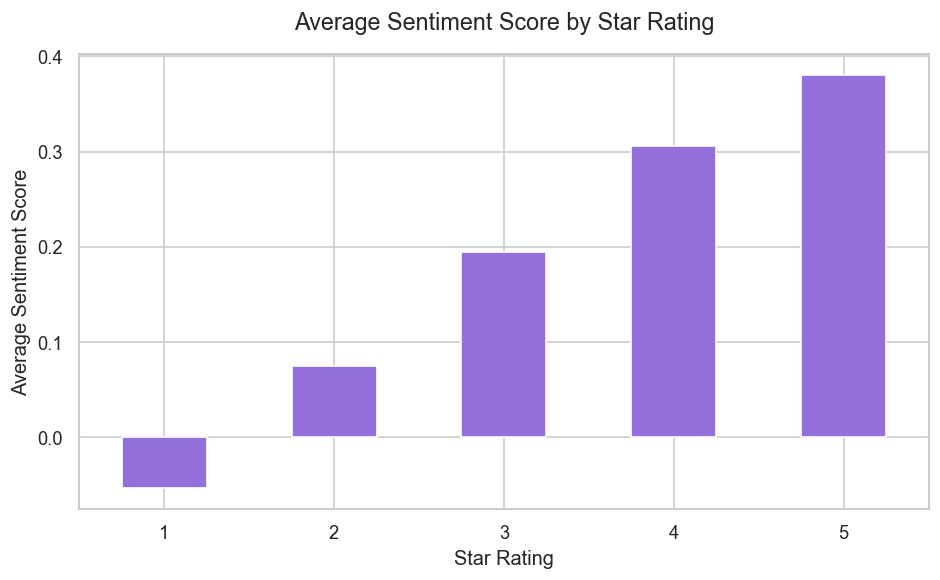

Insight: Sentiment increases with star rating, validating the model


In [23]:
# Validation: if the analysis is correct,
# higher star ratings should correlate with more positive sentiment

plt.figure(figsize=(8,5))
df_merged.groupby('stars_x')['sentiment_score'].mean().plot(
    kind='bar', color='mediumpurple', edgecolor='white'
)
plt.title('Average Sentiment Score by Star Rating', fontsize=14, pad=15)
plt.xlabel('Star Rating')
plt.ylabel('Average Sentiment Score')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('/Users/vipont/Desktop/data/outputs/04_stars_vs_sentiment.png')
plt.show()

print("Insight: Sentiment increases with star rating, validating the model")

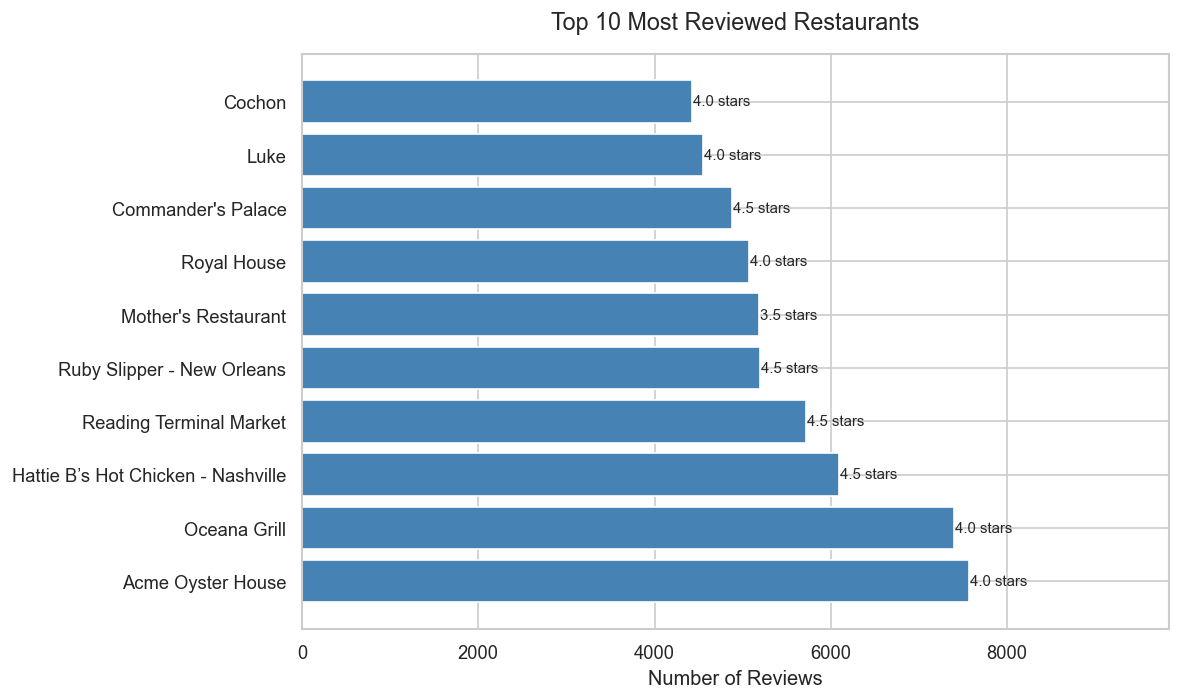

In [24]:
# Most reviewed restaurants (minimum 100 reviews)

top_restaurants = restaurants[restaurants['review_count'] >= 100]\
    .nlargest(10, 'review_count')[['name', 'city', 'stars', 'review_count']]

fig, ax = plt.subplots(figsize=(10,6))
ax.barh(top_restaurants['name'], top_restaurants['review_count'], color='steelblue')

for i, (reviews, stars) in enumerate(zip(top_restaurants['review_count'], top_restaurants['stars'])):
    ax.text(reviews + 10, i, f'{stars} stars', va='center', fontsize=9)

ax.set_xlim(0, top_restaurants['review_count'].max() * 1.3)
plt.title('Top 10 Most Reviewed Restaurants', fontsize=14, pad=15)
plt.xlabel('Number of Reviews')
plt.tight_layout()
plt.savefig('/Users/vipont/Desktop/data/outputs/05_top_restaurants.png')
plt.show()

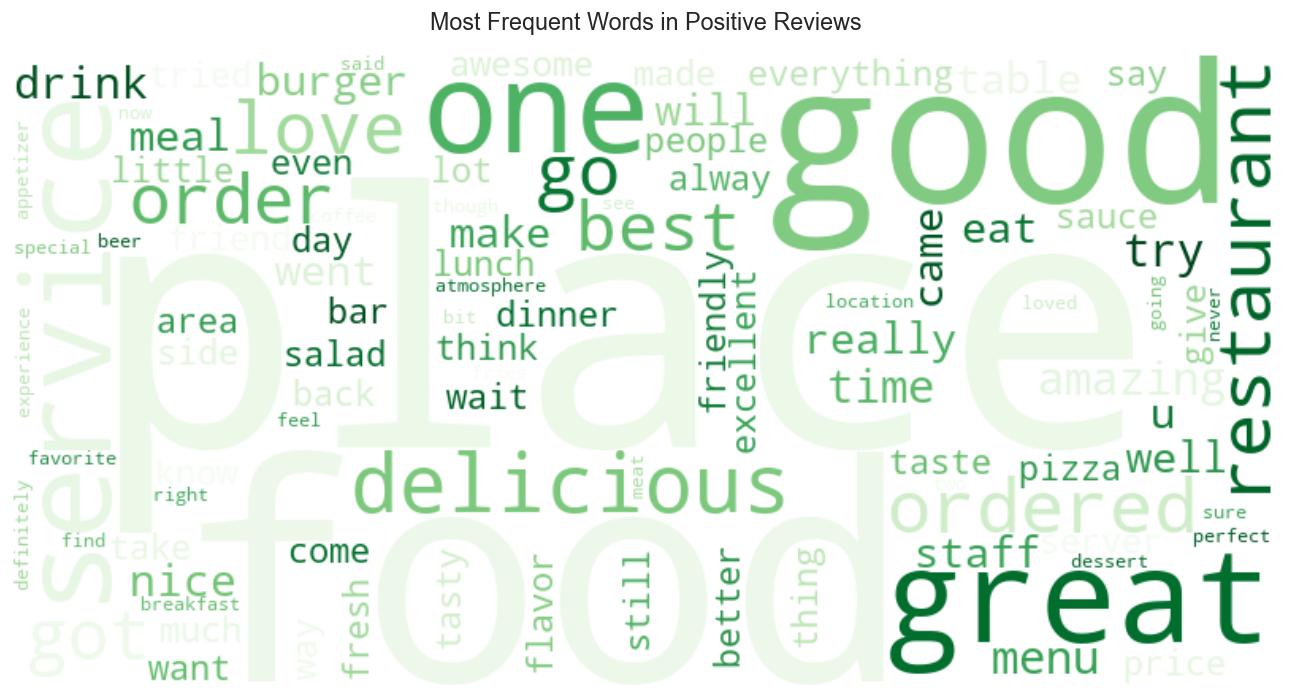

Insight: Satisfied customers highlight service and overall experience


In [25]:
# What words do satisfied customers use the most?

positive_text = ' '.join(
    df_merged[df_merged['sentiment'] == 'Positive']['text'].astype(str)
)

wordcloud = WordCloud(
    width=800, height=400,
    background_color='white',
    colormap='Greens',
    max_words=100
).generate(positive_text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Frequent Words in Positive Reviews', fontsize=14, pad=15)
plt.tight_layout()
plt.savefig('/Users/vipont/Desktop/data/outputs/06_wordcloud_positive.png')
plt.show()

print("Insight: Satisfied customers highlight service and overall experience")

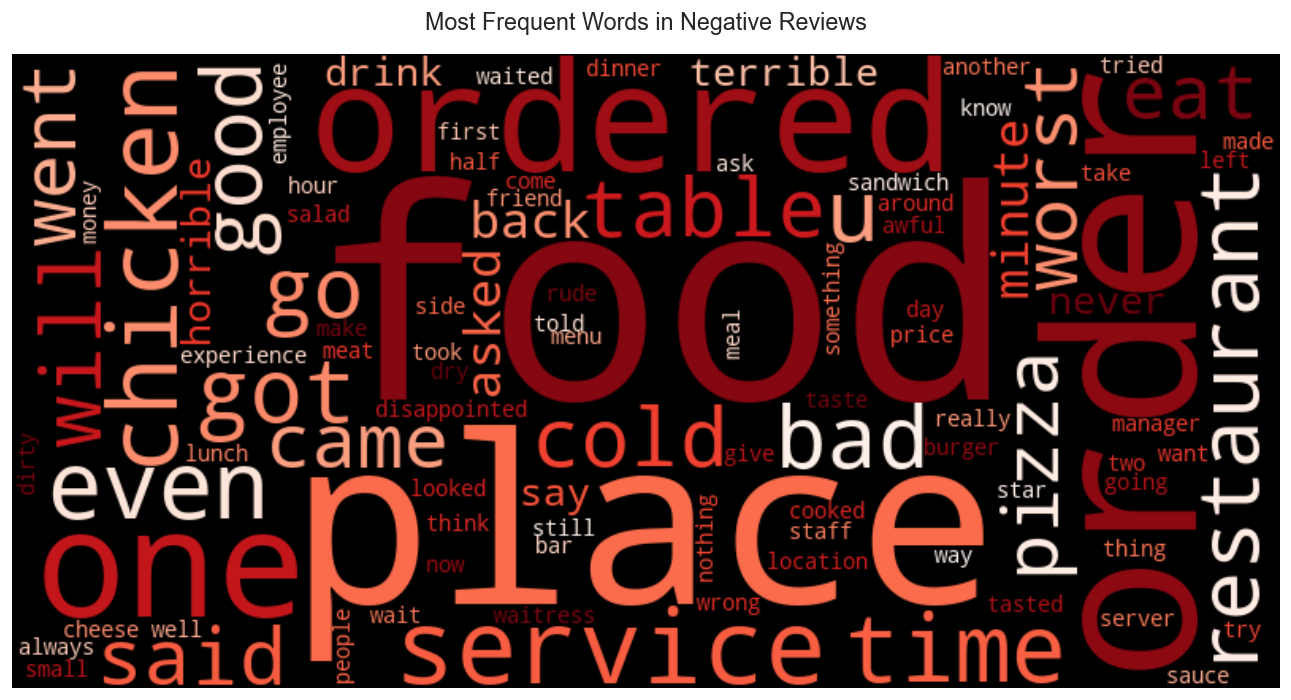

Insight: Complaints focus on waiting times and incorrect orders


In [26]:
# What do unhappy customers complain about?

negative_text = ' '.join(
    df_merged[df_merged['sentiment'] == 'Negative']['text'].astype(str)
)

wordcloud_neg = WordCloud(
    width=800, height=400,
    background_color='black',
    colormap='Reds',
    max_words=100
).generate(negative_text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud_neg, interpolation='bilinear')
plt.axis('off')
plt.title('Most Frequent Words in Negative Reviews', fontsize=14, pad=15)
plt.tight_layout()
plt.savefig('/Users/vipont/Desktop/data/outputs/07_wordcloud_negative.png')
plt.show()

print("Insight: Complaints focus on waiting times and incorrect orders")

In [27]:
print("""
KEY FINDINGS
============

1. RATINGS: Most restaurants have 4 stars.
   The dataset is skewed toward positive ratings.

2. GEOGRAPHY: Philadelphia has the highest concentration
   of restaurants in the dataset.

3. SENTIMENT: 79% of reviews are positive, only
   5% are negative.

4. MODEL VALIDATION: Sentiment scores align with star ratings,
   confirming the model works correctly.

5. KEY WORDS:
   - Positive reviews: great, service, place, food
   - Negative reviews: bad, ordered, wait, time
   Service quality and waiting times are the main
   differentiators between good and bad experiences.
""")


KEY FINDINGS

1. RATINGS: Most restaurants have 4 stars.
   The dataset is skewed toward positive ratings.

2. GEOGRAPHY: Philadelphia has the highest concentration
   of restaurants in the dataset.

3. SENTIMENT: 79% of reviews are positive, only
   5% are negative.

4. MODEL VALIDATION: Sentiment scores align with star ratings,
   confirming the model works correctly.

5. KEY WORDS:
   - Positive reviews: great, service, place, food
   - Negative reviews: bad, ordered, wait, time
   Service quality and waiting times are the main
   differentiators between good and bad experiences.

